<a href="https://colab.research.google.com/github/ClassNeuralNetwork/classification_spotify_music/blob/main/Projeto_Redes_Neurais_DataSetSpotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub[pandas-datasets]

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import kagglehub
import shap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [3]:
path = kagglehub.dataset_download("solomonameh/spotify-music-dataset")

print("Path to dataset files:", path)

100%|██████████| 573k/573k [00:00<00:00, 48.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/solomonameh/spotify-music-dataset/versions/1


In [4]:
dados = pd.read_csv('/root/.cache/kagglehub/datasets/solomonameh/spotify-music-dataset/versions/1/high_popularity_spotify_data.csv')

In [5]:
colunas = [
    'track_name',
    'track_artist',
    'energy',
    'tempo',
    'danceability',
    'playlist_genre',
    'loudness',
    'valence',
    'track_popularity',
    'duration_ms'
]

dados = dados[colunas]

display(dados.head(10))

,track_name,track_artist,energy,tempo,danceability,playlist_genre,loudness,valence,track_popularity,duration_ms
0,Die With A Smile,"Lady Gaga, Bruno Mars",0.592,157.969,0.521,pop,-7.777,0.535,100,251668
1,BIRDS OF A FEATHER,Billie Eilish,0.507,104.978,0.747,pop,-10.171,0.438,97,210373
2,That’s So True,Gracie Abrams,0.808,108.548,0.554,pop,-4.169,0.372,93,166300
3,Taste,Sabrina Carpenter,0.910,112.966,0.670,pop,-4.070,0.786,81,157280
4,APT.,"ROSÉ, Bruno Mars",0.783,149.027,0.777,pop,-4.477,0.939,98,169917
5,"Good Luck, Babe!",Chappell Roan,0.582,116.712,0.700,pop,-5.960,0.785,94,218424
6,Diet Pepsi,Addison Rae,0.561,150.069,0.669,pop,-6.538,0.841,88,169698
7,WILDFLOWER,Billie Eilish,0.247,148.101,0.467,pop,-12.002,0.126,93,261467
8,Sailor Song,Gigi Perez,0.416,94.926,0.492,pop,-10.439,0.297,71,211979
9,Timeless (with Playboi Carti),"The Weeknd, Playboi Carti",0.722,119.973,0.769,pop,-5.485,0.570,92,256000


In [6]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_name        1686 non-null   object 
 1   track_artist      1686 non-null   object 
 2   energy            1686 non-null   float64
 3   tempo             1686 non-null   float64
 4   danceability      1686 non-null   float64
 5   playlist_genre    1686 non-null   object 
 6   loudness          1686 non-null   float64
 7   valence           1686 non-null   float64
 8   track_popularity  1686 non-null   int64  
 9   duration_ms       1686 non-null   int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 131.8+ KB


In [7]:
saida = dados['playlist_genre']
entrada = dados.drop('playlist_genre', axis=1)

encoder = OneHotEncoder(sparse_output=False)
saida_encoded = encoder.fit_transform(saida.values.reshape(-1, 1))

print("Formato da saída codificada:", saida_encoded.shape)

Formato da saída codificada: (1686, 28)


In [67]:
entrada_treino, entrada_teste, saida_treino , saida_teste = train_test_split(entrada, saida_encoded, test_size=0.04, random_state=42)

In [68]:
colunas_categoricas = ['track_name', 'track_artist']
colunas_numericas = ['energy', 'tempo', 'danceability', 'loudness', 'valence', 'track_popularity', 'duration_ms']

# Inicializar o OneHotEncoder para lidar com novas categorias no conjunto de teste
encoder_cat = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Ajustar e transformar nos dados de treino
cat_treino_encoded = encoder_cat.fit_transform(entrada_treino[colunas_categoricas])
cat_teste_encoded = encoder_cat.transform(entrada_teste[colunas_categoricas])

# Padronizar as colunas numéricas
padronizador = StandardScaler()
num_treino_scaled = padronizador.fit_transform(entrada_treino[colunas_numericas])
num_teste_scaled = padronizador.transform(entrada_teste[colunas_numericas])

# Concatenar as features numéricas padronizadas com as categóricas codificadas
X_treino_processado = np.hstack((num_treino_scaled, cat_treino_encoded))
X_teste_processado = np.hstack((num_teste_scaled, cat_teste_encoded))

print("Formato do X_treino final:", X_treino_processado.shape)
print("Formato do X_teste final:", X_teste_processado.shape)

Formato do X_treino final: (1618, 2368)
Formato do X_teste final: (68, 2368)


In [69]:
opt = tf.keras.optimizers.Adam(learning_rate=0.02)

In [70]:
len(saida.unique())

28

In [71]:
X_treino = X_treino_processado
X_teste = X_teste_processado

modelo_sp = Sequential([
    tf.keras.Input(shape=(X_treino.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(len(saida.unique()), activation='softmax')
])

modelo_sp.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

historico = modelo_sp.fit(X_treino, saida_treino, epochs=100, batch_size=32, validation_split=0.1)

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1161 - loss: 3.2908 - val_accuracy: 0.1358 - val_loss: 3.2258
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1387 - loss: 3.0861 - val_accuracy: 0.1358 - val_loss: 2.9318
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1559 - loss: 2.7358 - val_accuracy: 0.2037 - val_loss: 2.6140
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2445 - loss: 2.4329 - val_accuracy: 0.3272 - val_loss: 2.3623
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3310 - loss: 2.2176 - val_accuracy: 0.3580 - val_loss: 2.2398
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3626 - loss: 2.0478 - val_accuracy: 0.3519 - val_loss: 2.1596
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4183 - loss: 1.8829 - val_accuracy: 0.3765 - val_loss: 2.0973
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4650 - loss: 1.7066 - val_accuracy: 0.3951 - 

In [72]:
modelo_sp.save('Spotify_Classification.keras')

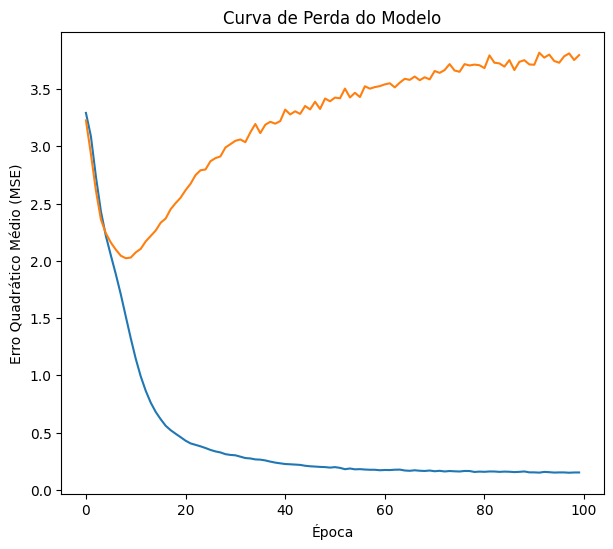

In [73]:
plt.figure(figsize=(7, 6))
plt.plot(historico.history['loss'])
plt.plot(historico.history['val_loss'])
plt.title('Curva de Perda do Modelo')
plt.ylabel('Erro Quadrático Médio (MSE)')
plt.xlabel('Época')
plt.show()

In [74]:
previsoes_prob = modelo_sp.predict(X_teste)

classes_preditas = np.argmax(previsoes_prob, axis=1)
classes_reais =  np.argmax(saida_teste, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [75]:
print(classification_report(classes_reais, classes_preditas))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         1
           2       0.00      0.00      0.00         3
           3       1.00      0.33      0.50         3
           4       0.00      0.00      0.00         1
           5       1.00      1.00      1.00         1
           7       1.00      0.07      0.13        14
           9       0.10      0.33      0.15         3
          10       0.43      0.50      0.46         6
          12       0.00      0.00      0.00         1
          16       0.00      0.00      0.00         1
          17       0.50      0.33      0.40         3
          19       1.00      0.67      0.80         3
          20       0.27      0.58      0.37        12
          21       0.50      1.00      0.67         1
          22       0.00      0.00      0.00         1
          24       0.83      0.77      0.80        13

    accuracy              

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


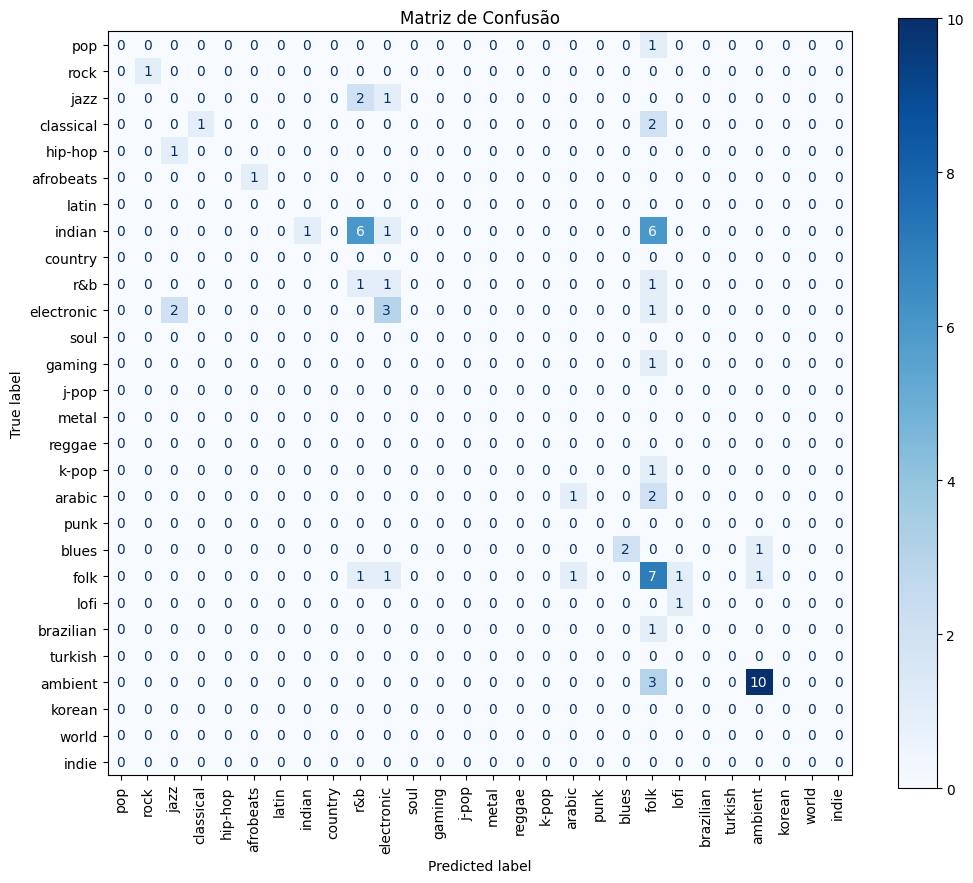

In [76]:
matriz_confusao = confusion_matrix(classes_reais, classes_preditas, labels=range(len(saida.unique())))

fig, ax = plt.subplots(figsize=(12, 10))
display_matriz = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=saida.unique())
display_matriz.plot(cmap=plt.cm.Blues, values_format='d', ax=ax, xticks_rotation='vertical')
plt.title('Matriz de Confusão')
plt.show()

In [77]:
explainer = shap.KernelExplainer(modelo_sp.predict, X_teste[:50])
shap_values = explainer.shap_values(X_teste)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


  0%|          | 0/68 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
3341/3341 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
3341/3341 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
3341/3341 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
3341/3341 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
3341/3341 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
3341/3341 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
3341/3341 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
3341/3341 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
3341/3341 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
3341/3341 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
3341/3341 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
3341/3341 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

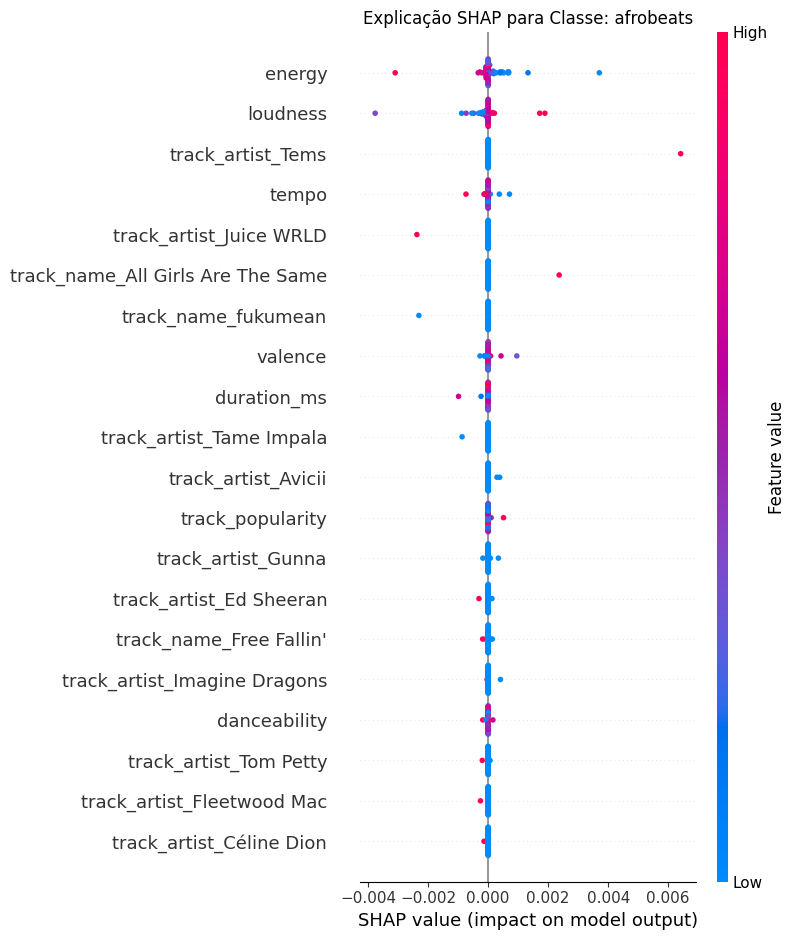

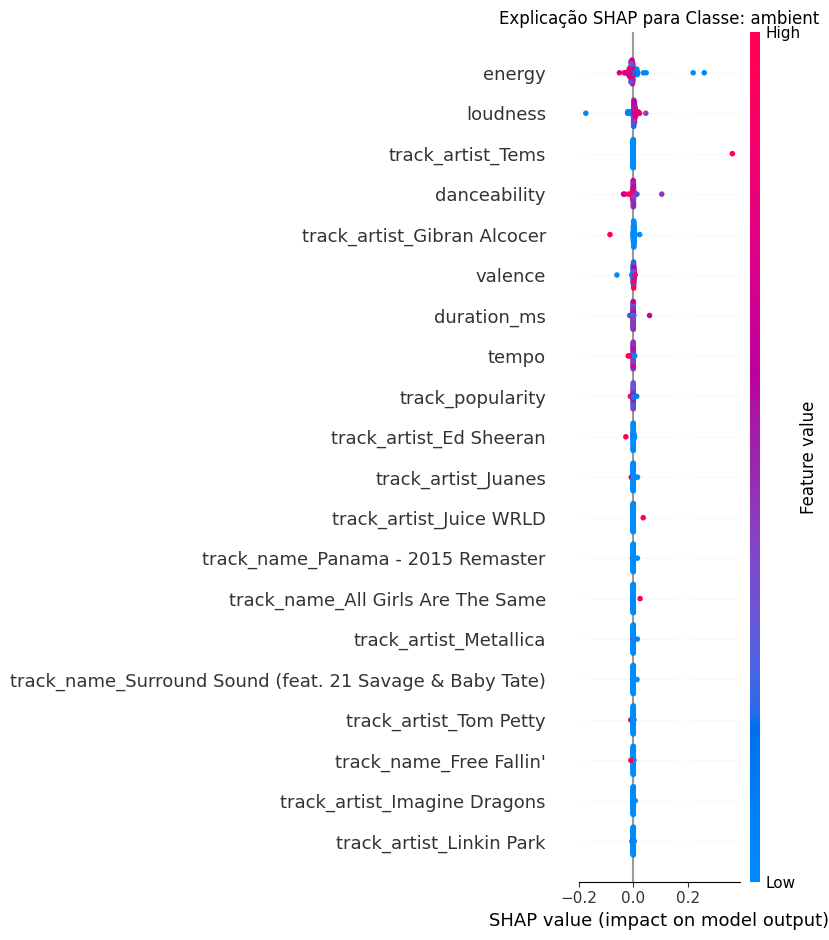

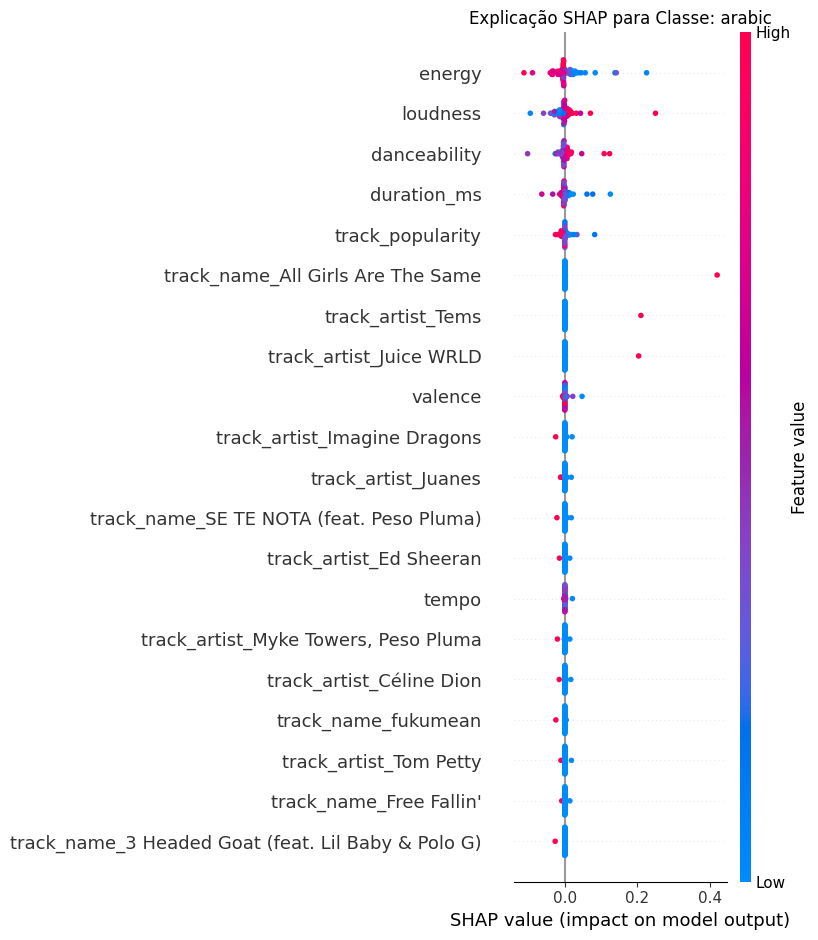

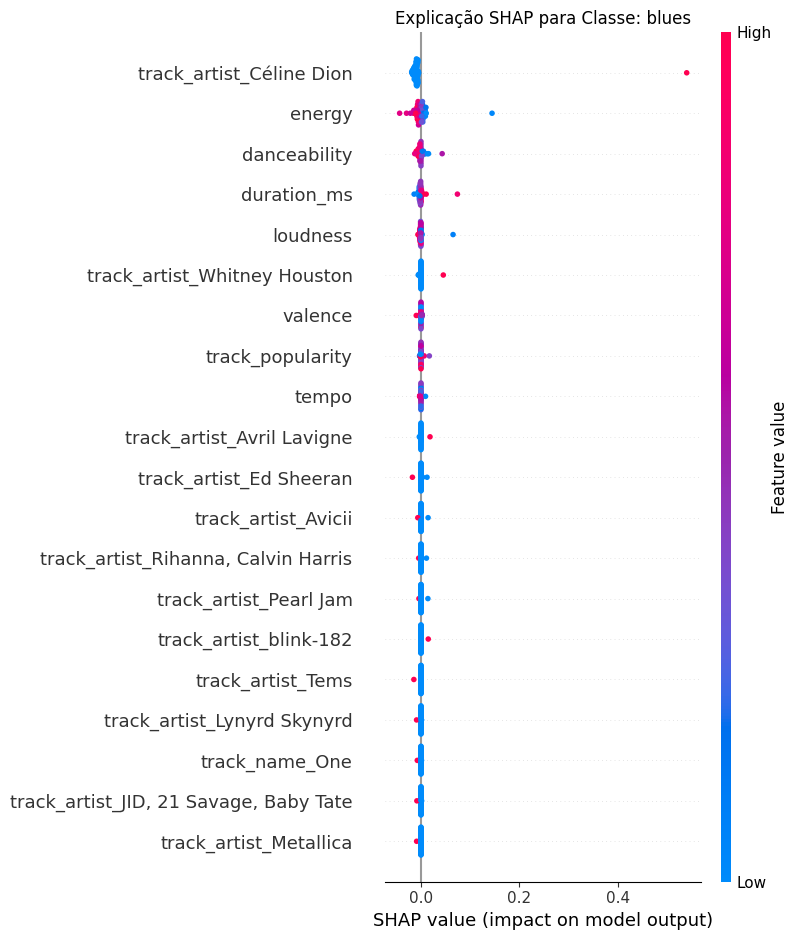

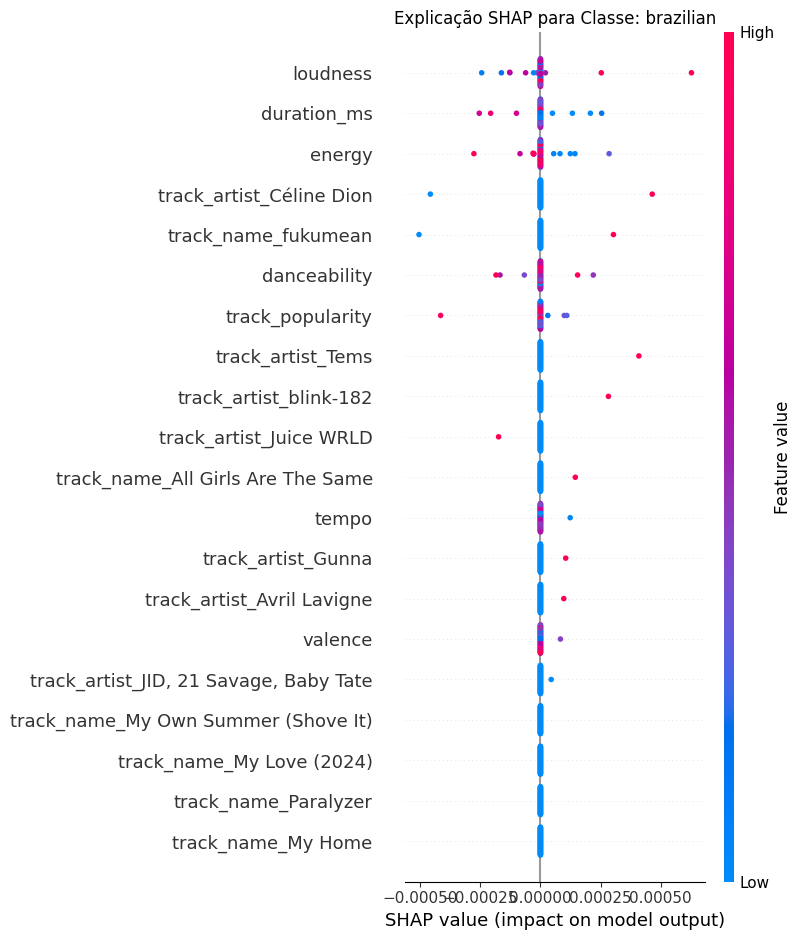

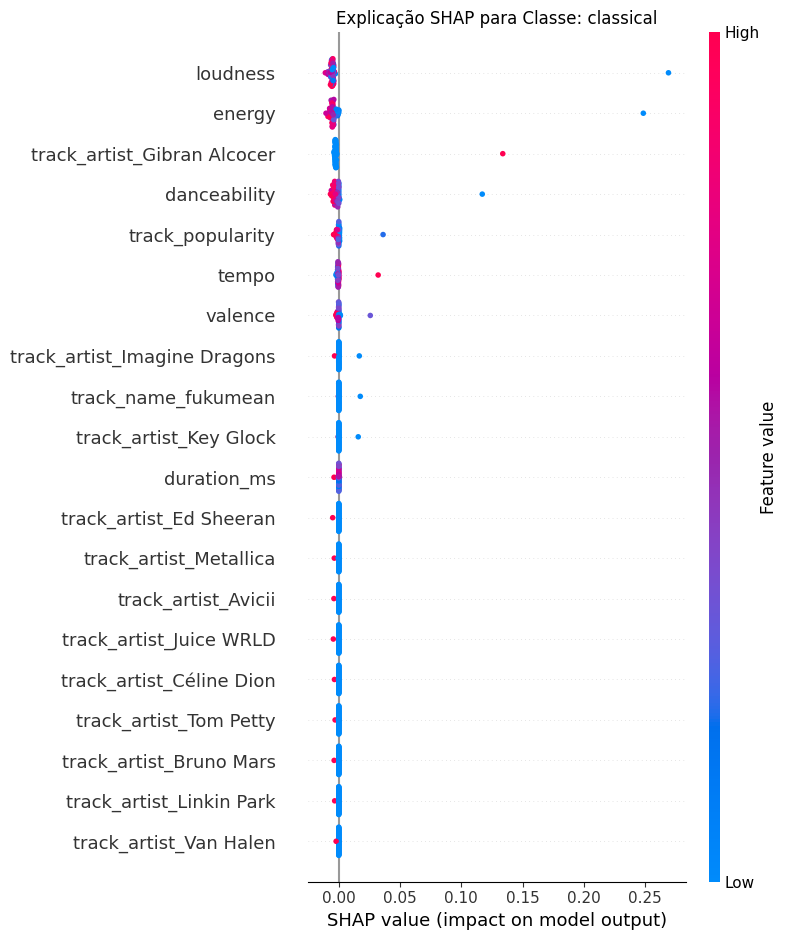

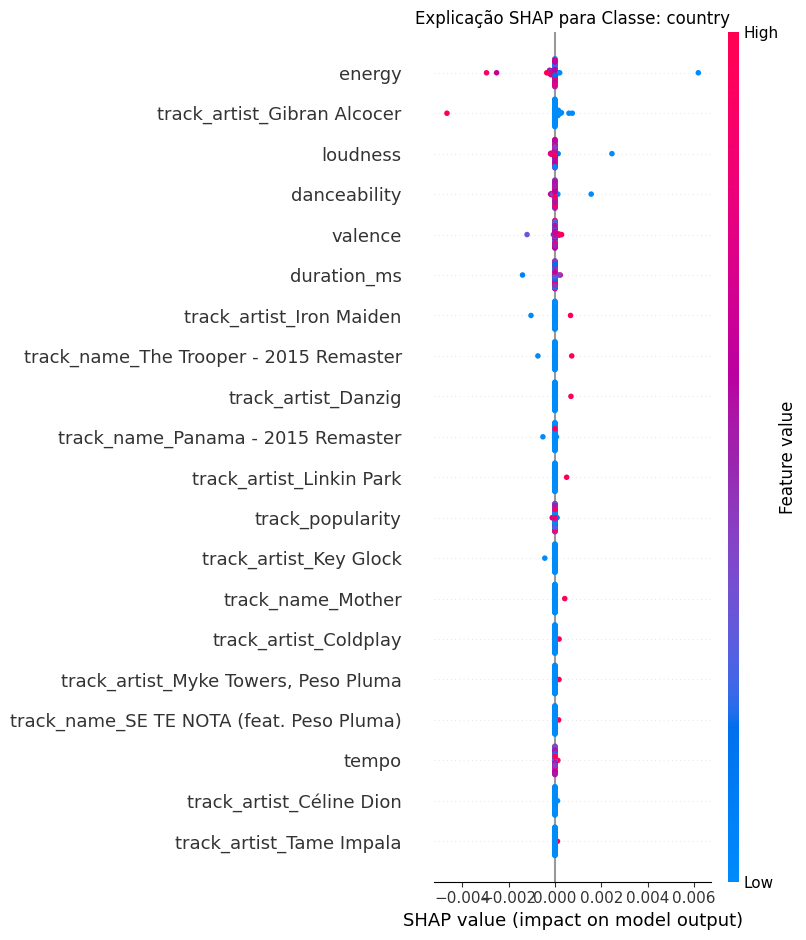

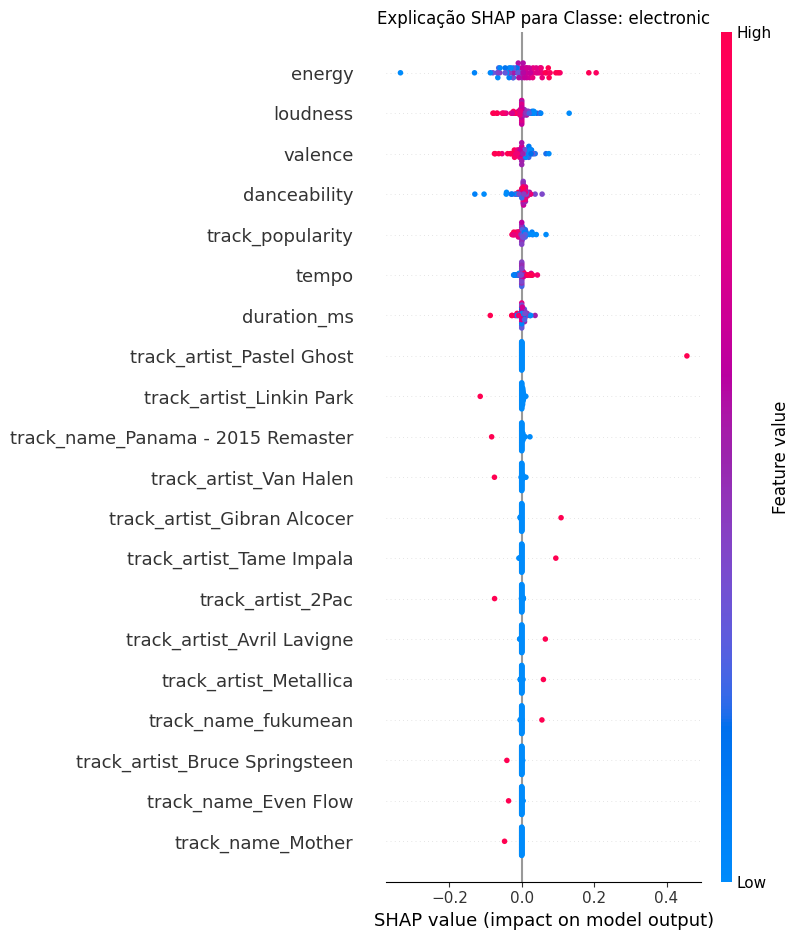

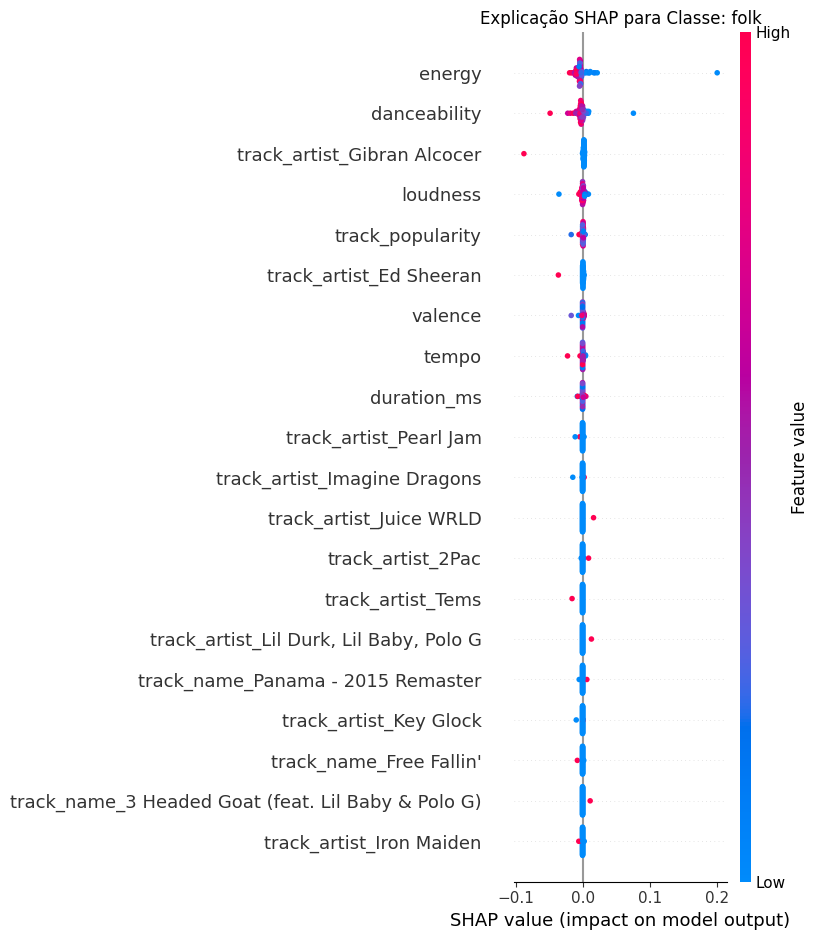

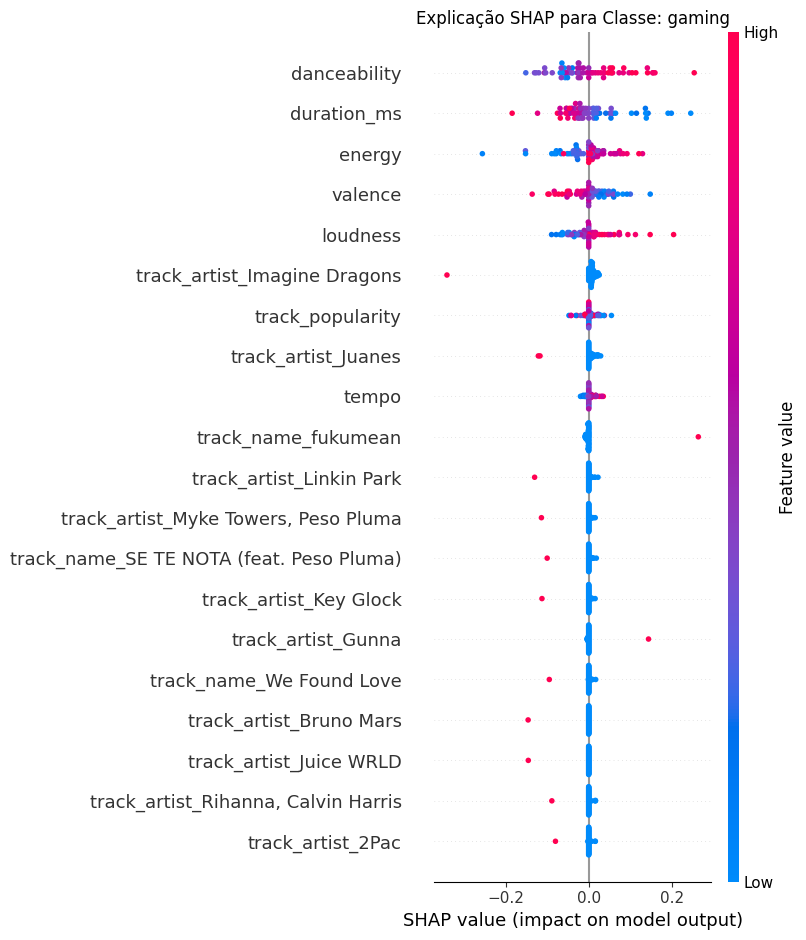

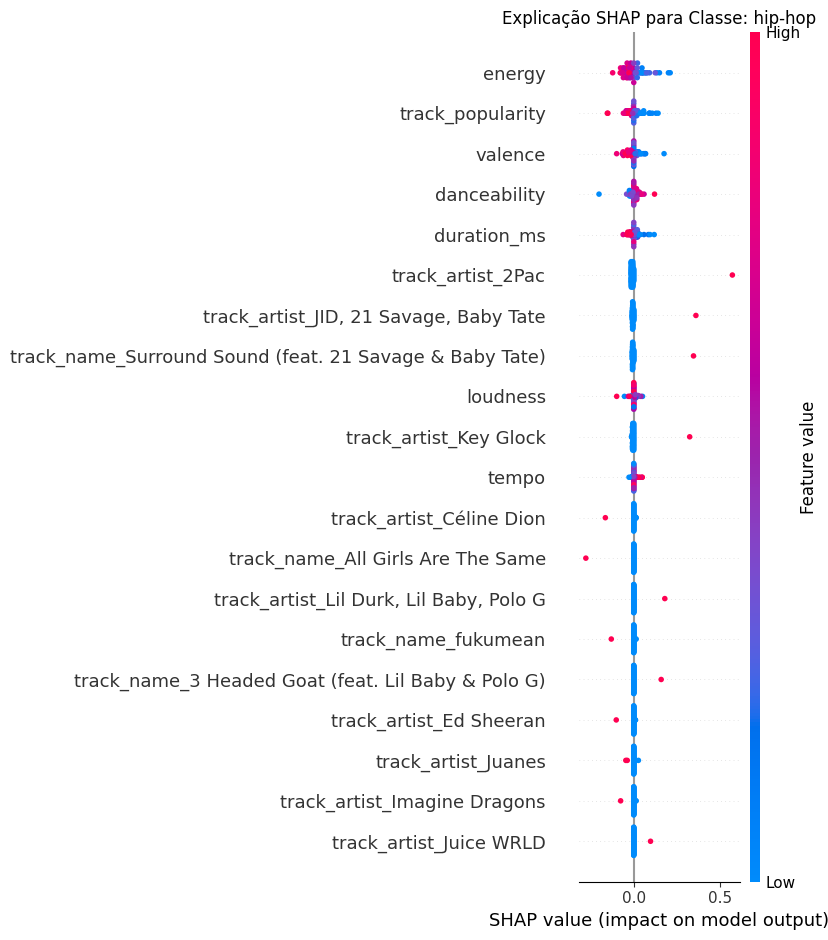

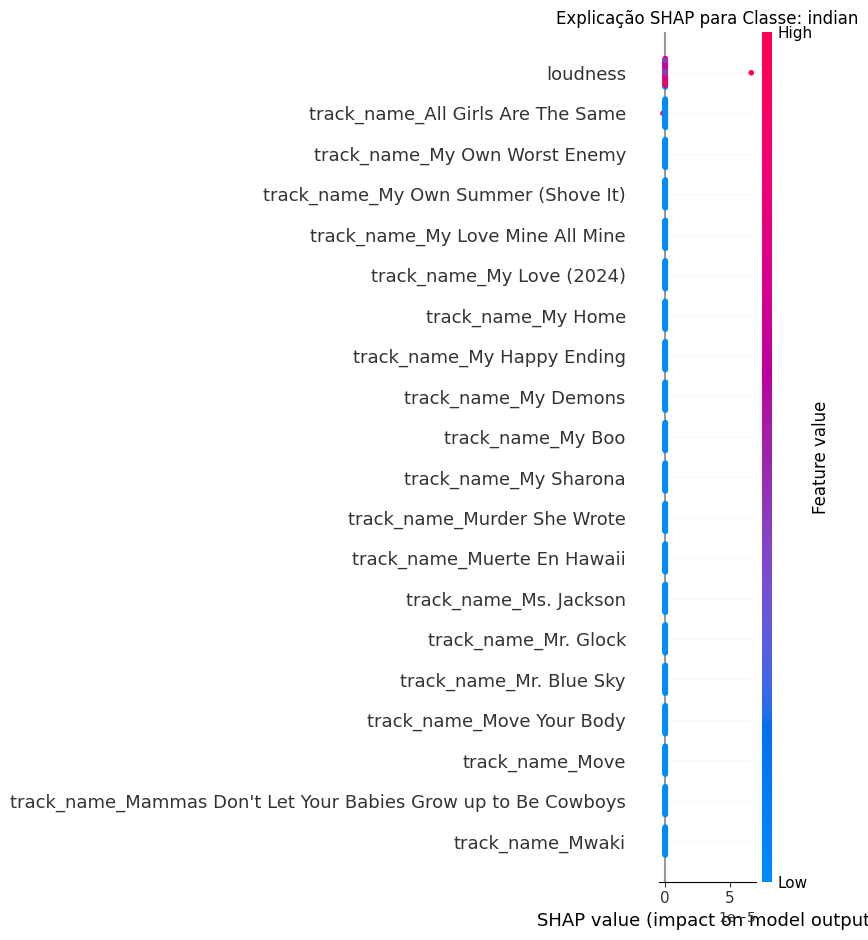

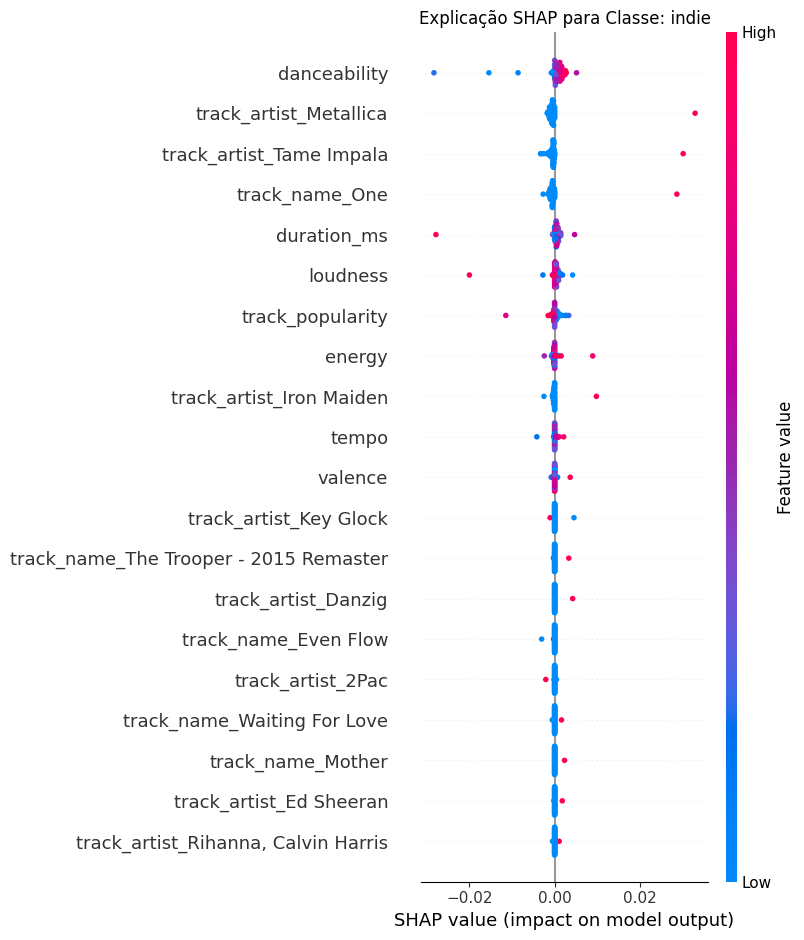

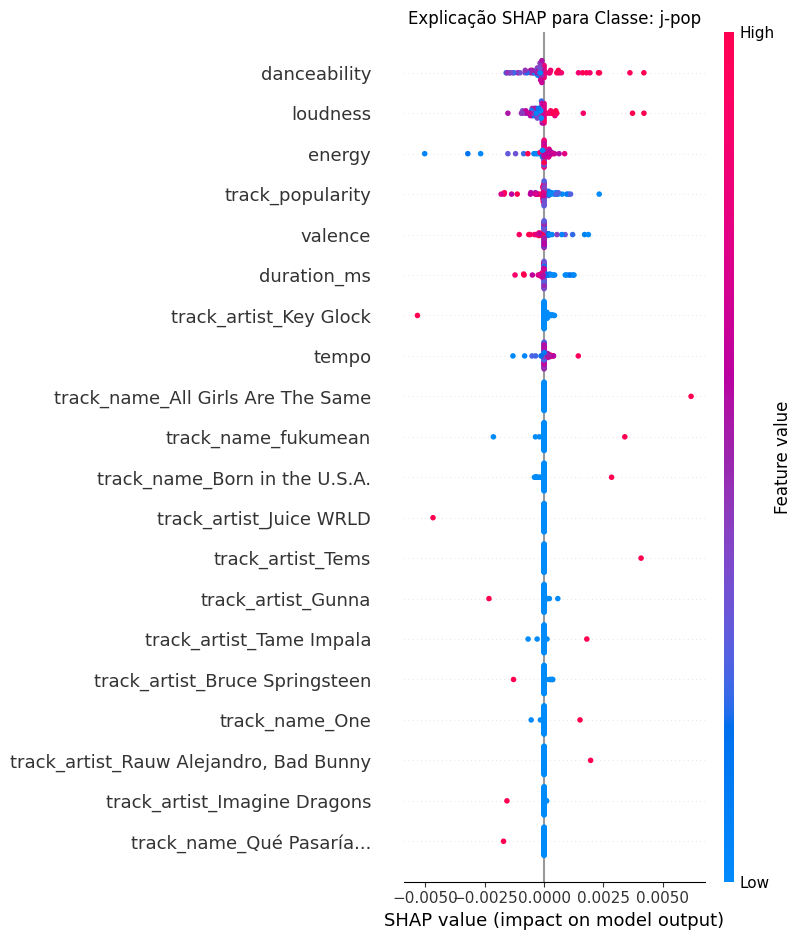

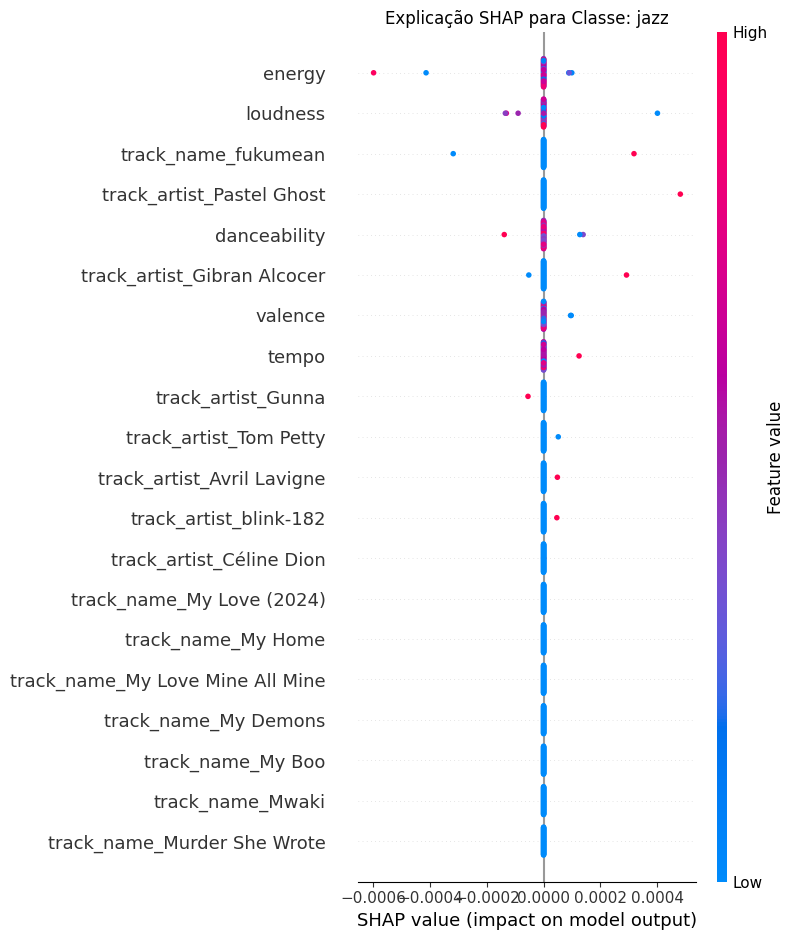

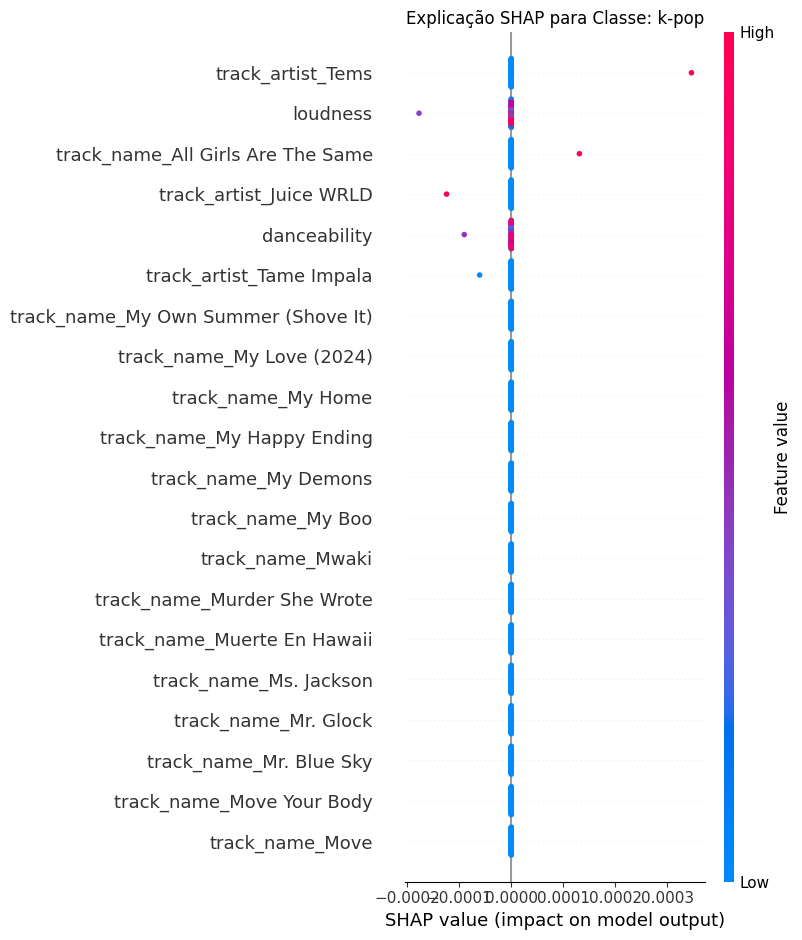

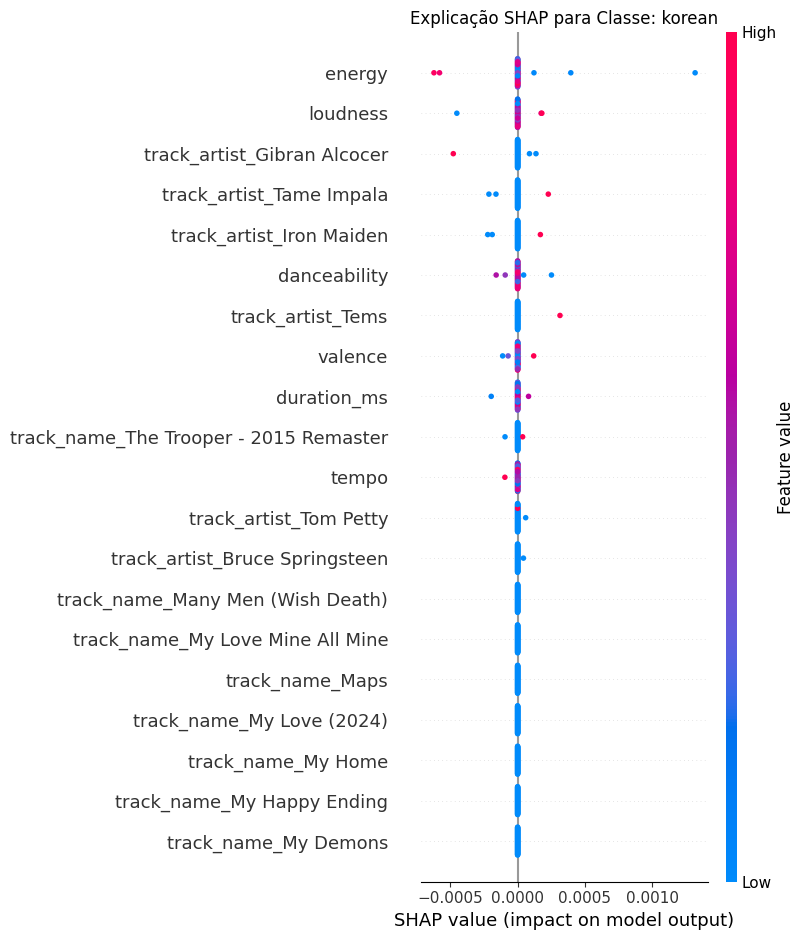

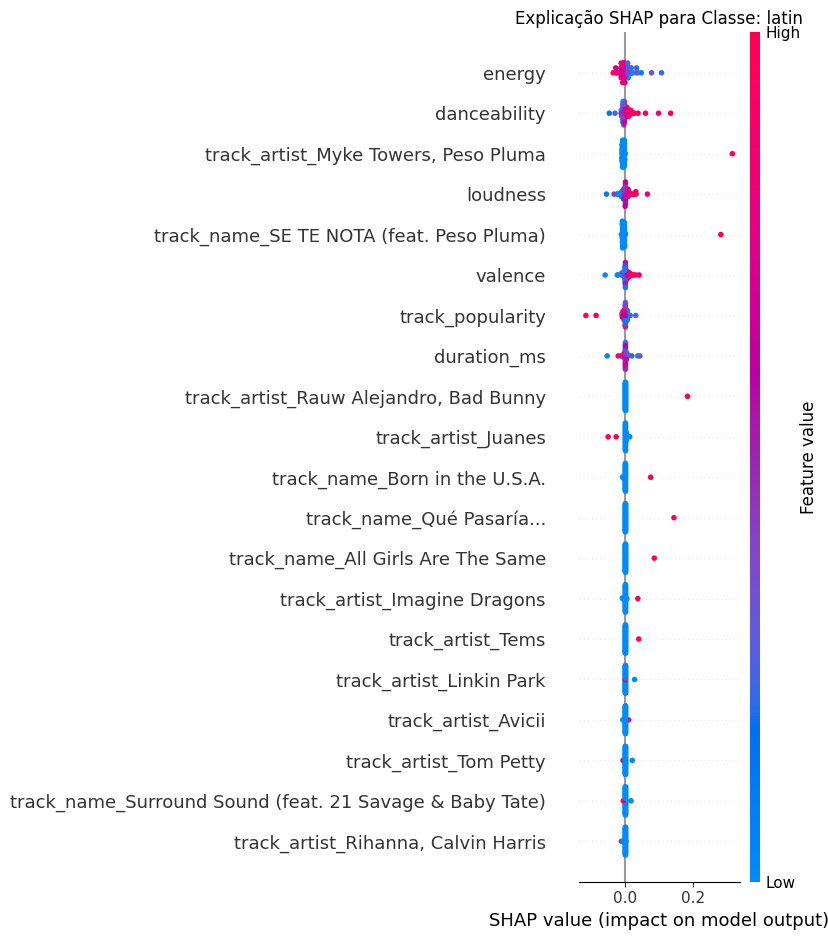

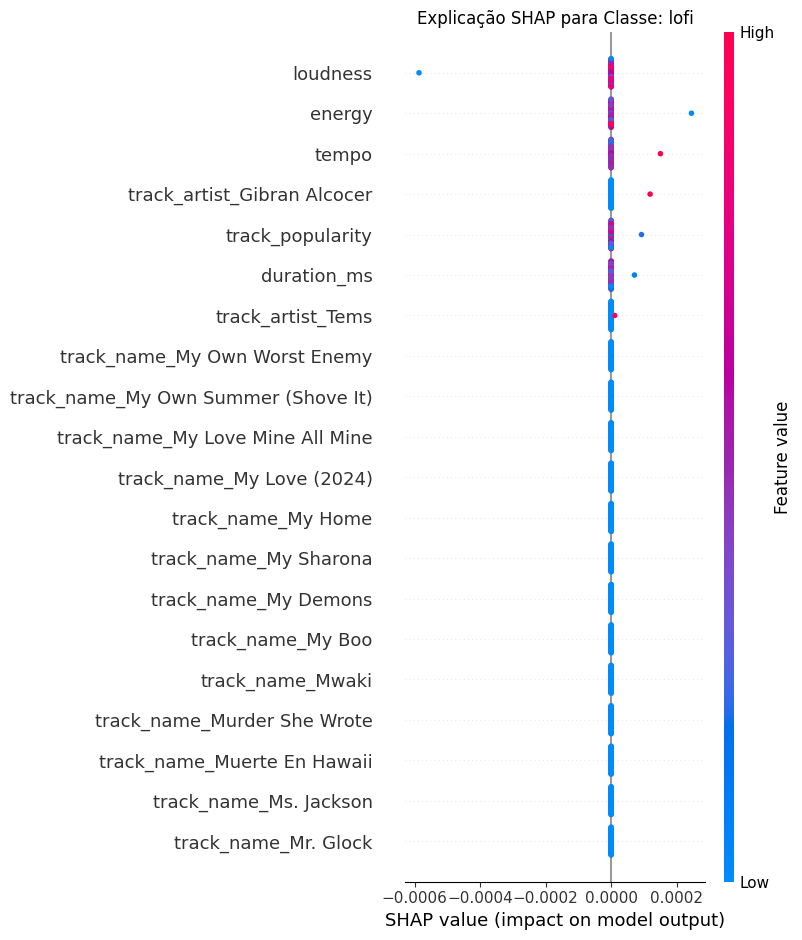

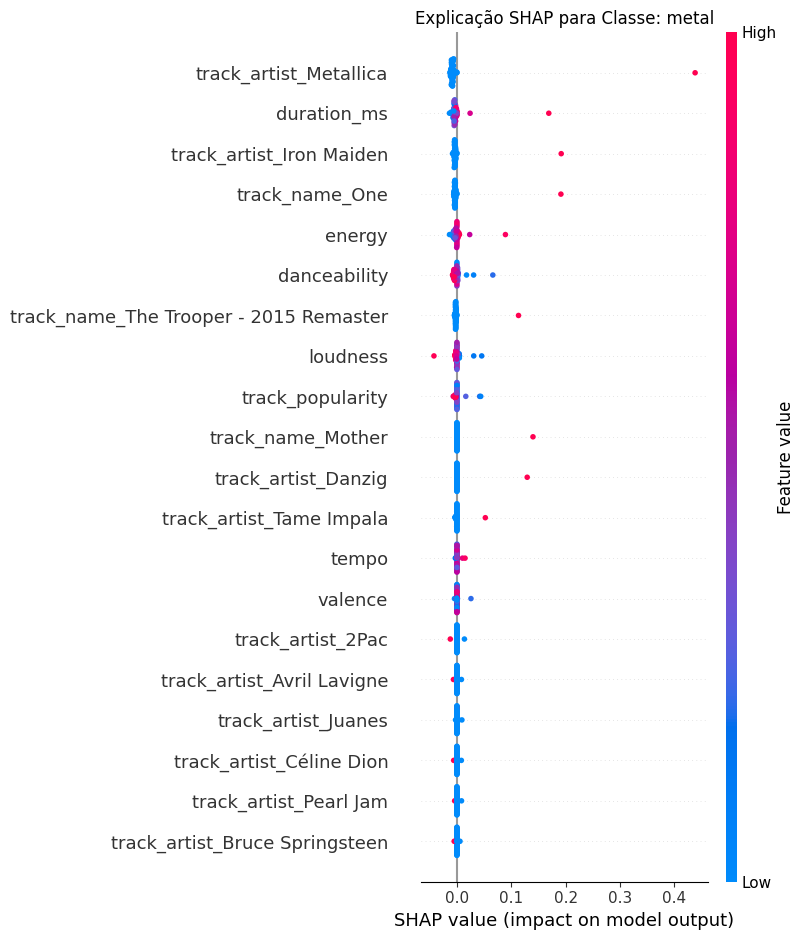

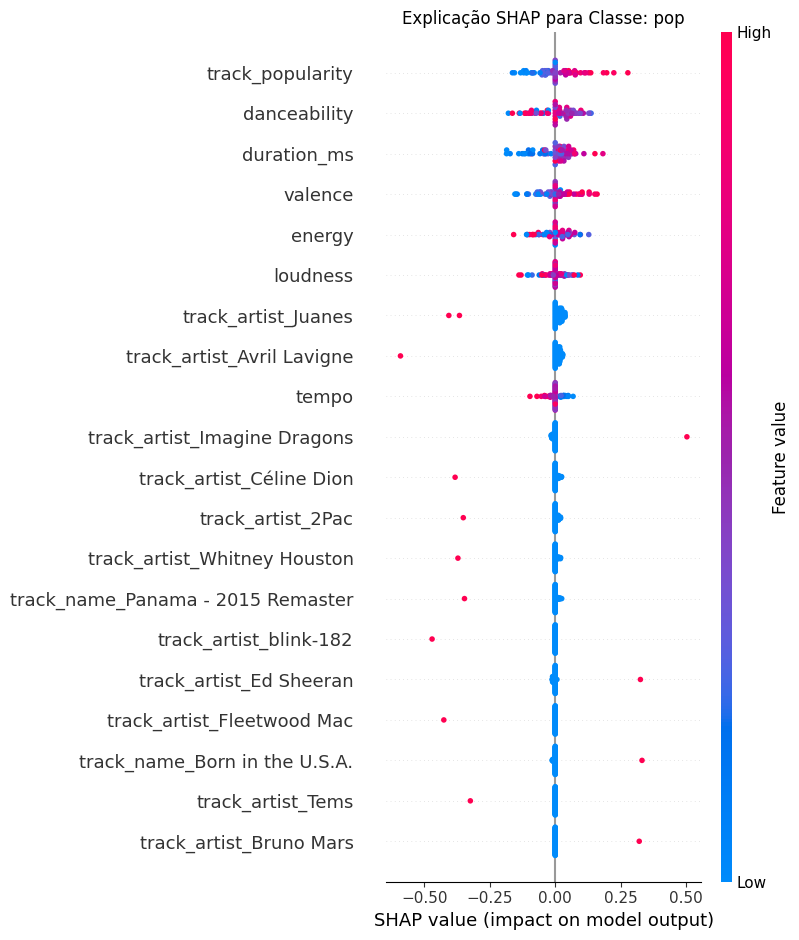

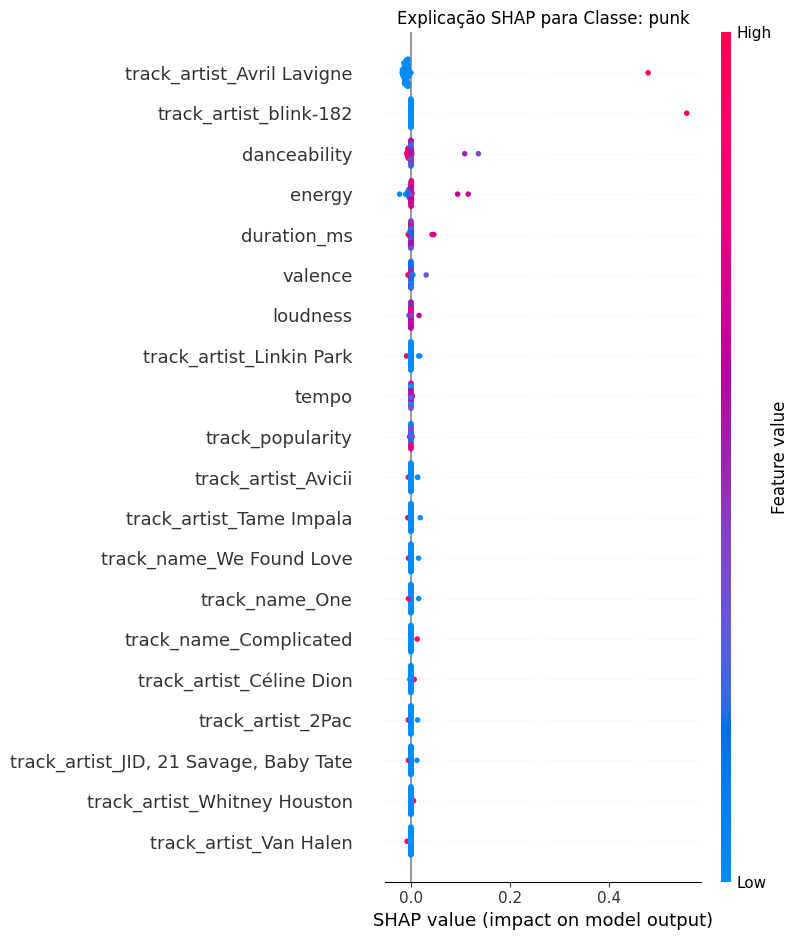

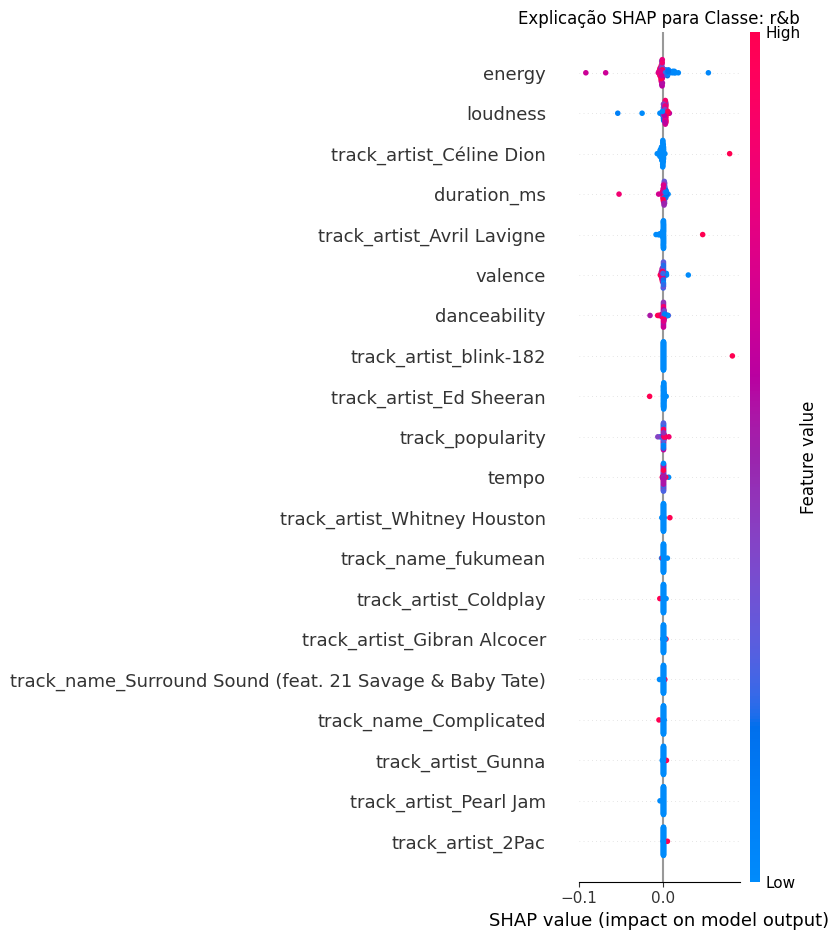

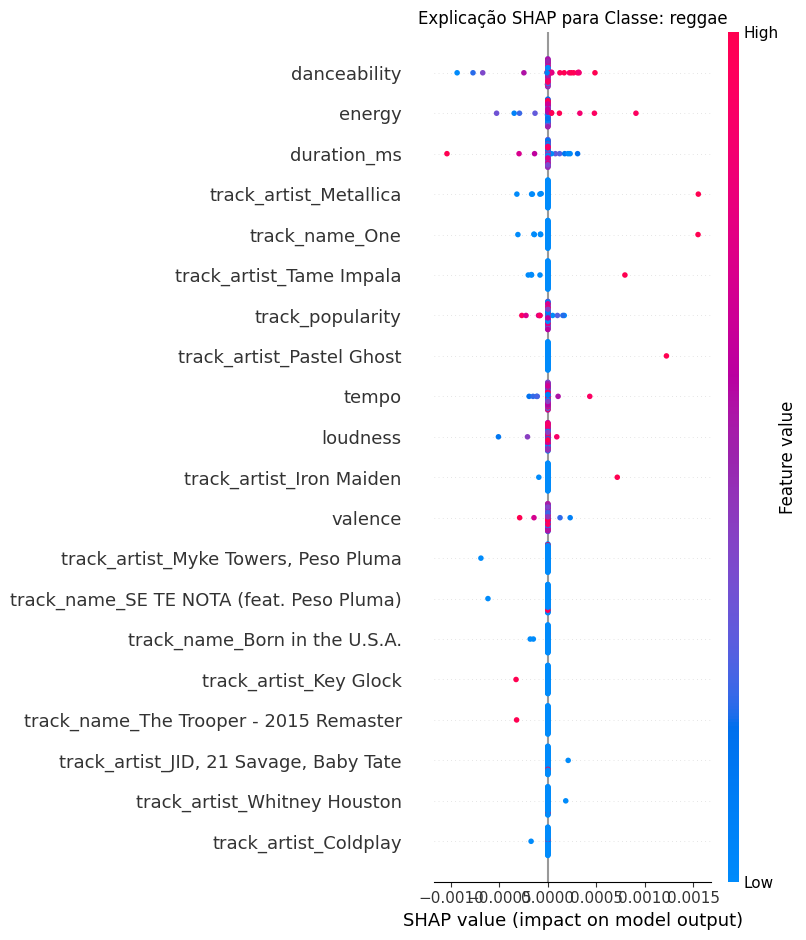

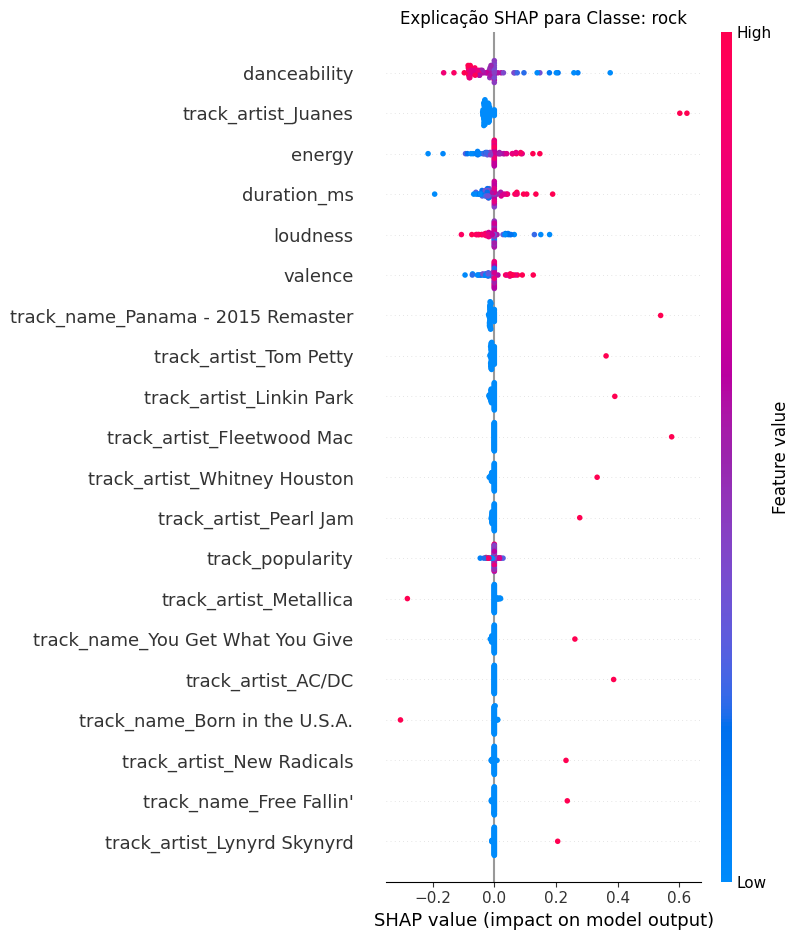

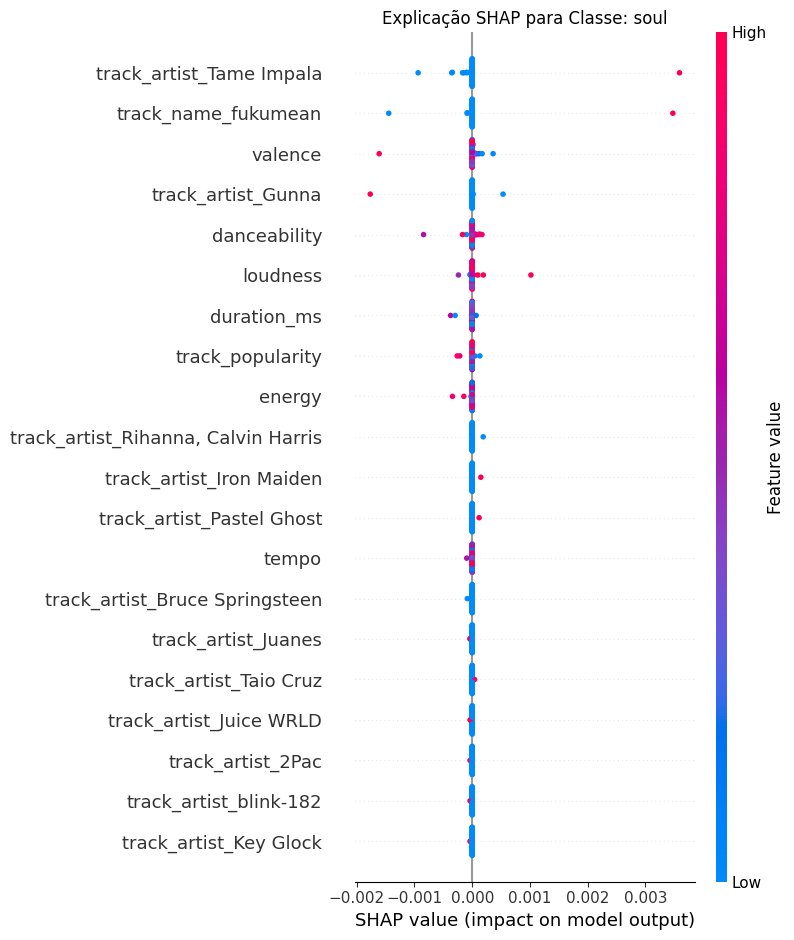

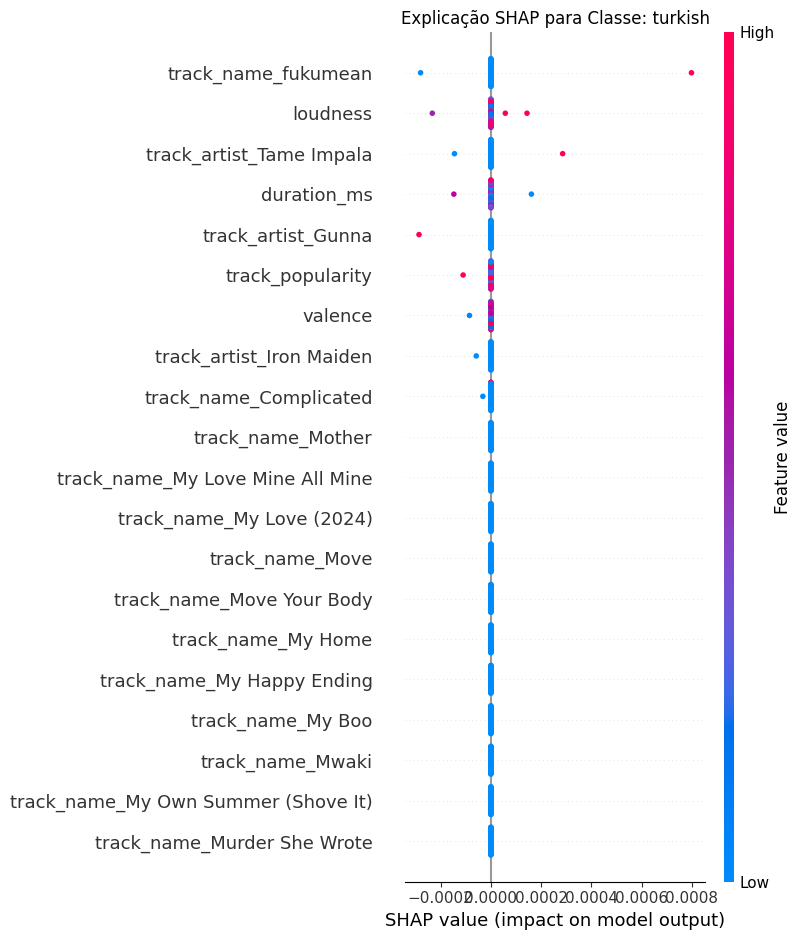

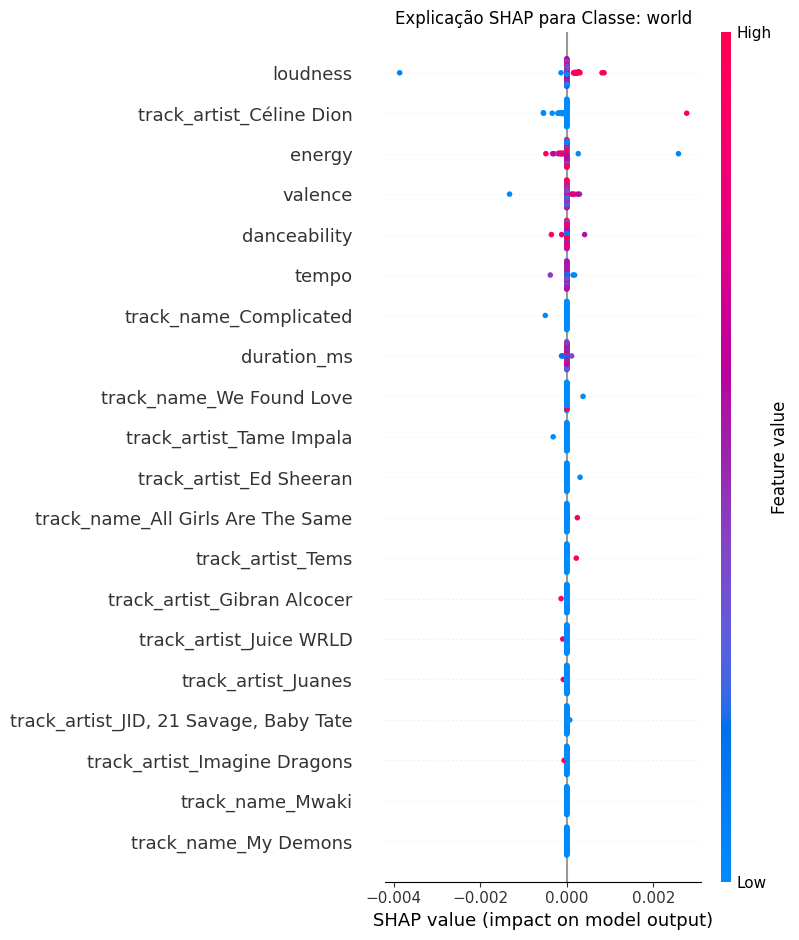

In [78]:
class_names = list(encoder.categories_[0])

categorical_feature_names = list(encoder_cat.get_feature_names_out(colunas_categoricas))

all_feature_names = list(colunas_numericas) + categorical_feature_names

for i, class_name in enumerate(class_names):
  plt.figure(figsize=(6, 3))
  plt.title(f"Explicação SHAP para Classe: {class_name}")
  shap_val_class = shap_values[:, :, i]

  shap.summary_plot(shap_val_class, X_teste, feature_names=all_feature_names)
  plt.show()